In [1]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"Seeds fixed: {SEED}")

Seeds fixed: 42


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

print("PROJECT_ROOT =", PROJECT_ROOT)

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/alzheimer-ai/


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

os.makedirs(PROJECT_ROOT + 'reports/figures', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'data/processed', exist_ok=True)

df = pd.read_csv(PROJECT_ROOT + 'data/processed/oasis_day2_metadata.csv')

print("Shape:", df.shape)
print(df['Label'].value_counts())
print(df[['Subject ID', 'MRI ID', 'Group', 'CDR', 'Label', 'y', 'split']].head())

Shape: (373, 20)
Label
CN     190
MA     146
MCI     37
Name: count, dtype: int64
  Subject ID         MRI ID        Group  CDR Label  y  split
0  OAS2_0001  OAS2_0001_MR1  Nondemented  0.0    CN  0  train
1  OAS2_0001  OAS2_0001_MR2  Nondemented  0.0    CN  0  train
2  OAS2_0002  OAS2_0002_MR1     Demented  0.5    MA  2    val
3  OAS2_0002  OAS2_0002_MR2     Demented  0.5    MA  2    val
4  OAS2_0002  OAS2_0002_MR3     Demented  0.5    MA  2    val


In [4]:
numeric_vars = ['MMSE', 'nWBV', 'Age', 'EDUC', 'eTIV', 'ASF', 'y']

corr = df[numeric_vars].corr()

print("Correlation matrix:")
display(corr)

corr_path = PROJECT_ROOT + 'data/processed/feature_correlation_matrix.csv'
corr.to_csv(corr_path)

print("Saved:", corr_path)

Correlation matrix:


,MMSE,nWBV,Age,EDUC,eTIV,ASF,y
MMSE,1.000000,0.341315,0.055848,0.196159,-0.028163,0.035034,-0.595977
nWBV,0.341315,1.000000,-0.518359,-0.012200,-0.210122,0.213476,-0.313963
Age,0.055848,-0.518359,1.000000,-0.027886,0.042348,-0.035067,-0.044175
EDUC,0.196159,-0.012200,-0.027886,1.000000,0.257015,-0.241752,-0.236560
eTIV,-0.028163,-0.210122,0.042348,0.257015,1.000000,-0.988877,-0.028052
ASF,0.035034,0.213476,-0.035067,-0.241752,-0.988877,1.000000,0.021557
y,-0.595977,-0.313963,-0.044175,-0.236560,-0.028052,0.021557,1.000000


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/feature_correlation_matrix.csv


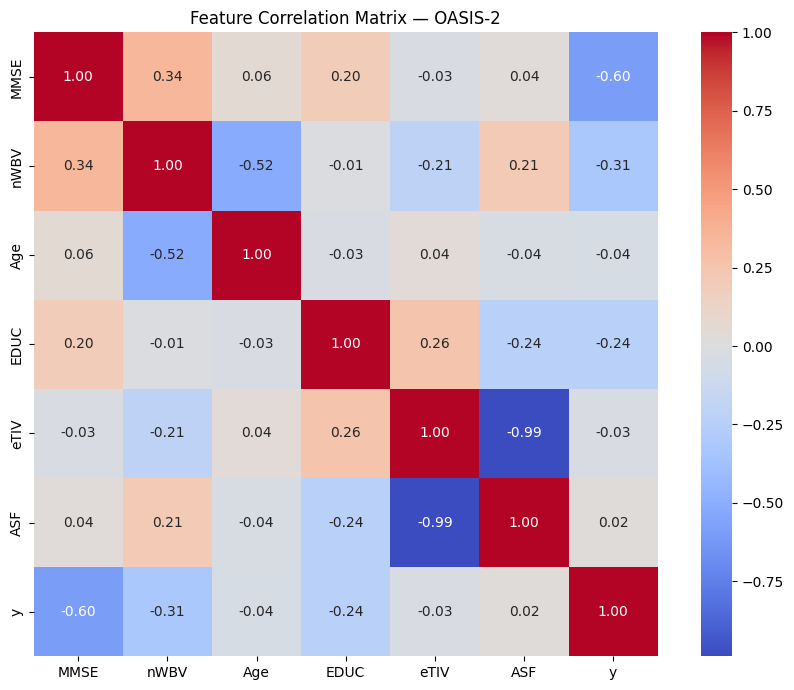

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/feature_correlation_matrix.png


In [5]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Matrix — OASIS-2")
plt.tight_layout()

fig_path = PROJECT_ROOT + 'reports/figures/feature_correlation_matrix.png'
plt.savefig(fig_path, dpi=150)
plt.show()

print("Saved:", fig_path)

In [6]:
print("Important correlations:")

pairs = [
    ('nWBV', 'eTIV'),
    ('eTIV', 'ASF'),
    ('nWBV', 'ASF'),
    ('MMSE', 'y'),
    ('nWBV', 'y'),
    ('Age', 'y')
]

for a, b in pairs:
    r = corr.loc[a, b]
    print(f"{a:<6} vs {b:<6}: r = {r:.4f}")

Important correlations:
nWBV   vs eTIV  : r = -0.2101
eTIV   vs ASF   : r = -0.9889
nWBV   vs ASF   : r = 0.2135
MMSE   vs y     : r = -0.5960
nWBV   vs y     : r = -0.3140
Age    vs y     : r = -0.0442


In [7]:
print("=== ANOVA one-way — separability per class ===")

anova_results = []

for var in ['MMSE', 'nWBV', 'Age', 'EDUC', 'eTIV']:
    groups = [
        df[df['Label'] == c][var].dropna().values
        for c in ['CN', 'MCI', 'MA']
    ]

    f, p = stats.f_oneway(*groups)
    significant = p < 0.05

    print(f"  {var:<8}: F={f:.2f}, p={p:.4f}  {'significant' if significant else 'not significant'}")

    anova_results.append({
        'variable': var,
        'F_statistic': f,
        'p_value': p,
        'significant_p_lt_0_05': significant
    })

anova_df = pd.DataFrame(anova_results)

anova_path = PROJECT_ROOT + 'data/processed/anova_feature_separability.csv'
anova_df.to_csv(anova_path, index=False)

print("Saved:", anova_path)

=== ANOVA one-way — separability per class ===
  MMSE    : F=111.73, p=0.0000  significant
  nWBV    : F=20.58, p=0.0000  significant
  Age     : F=3.13, p=0.0448  significant
  EDUC    : F=13.49, p=0.0000  significant
  eTIV    : F=0.67, p=0.5103  not significant
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/anova_feature_separability.csv


In [8]:
df['MMSE_nWBV_ratio'] = df['MMSE'] / (df['nWBV'] * 30 + 1e-8)
df['Age_atrophy'] = df['Age'] * (1 - df['nWBV'])

print(df[['MMSE', 'nWBV', 'Age', 'MMSE_nWBV_ratio', 'Age_atrophy']].head())

   MMSE   nWBV  Age  MMSE_nWBV_ratio  Age_atrophy
0  27.0  0.696   87         1.293103       26.448
1  30.0  0.681   88         1.468429       28.072
2  23.0  0.736   75         1.041667       19.800
3  28.0  0.713   76         1.309023       21.812
4  22.0  0.701   80         1.046125       23.920


In [9]:
output_path = PROJECT_ROOT + 'data/processed/oasis_feature_engineered.csv'

df.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Shape:", df.shape)

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/oasis_feature_engineered.csv
Shape: (373, 22)


In [10]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git status

!git add notebooks/02b_feature_engineering.ipynb
!git add reports/figures/feature_correlation_matrix.png
!git add -f data/processed/feature_correlation_matrix.csv
!git add -f data/processed/anova_feature_separability.csv
!git add -f data/processed/oasis_feature_engineered.csv

!git commit -m "feat: add feature engineering analysis"

!git status

/content/drive/MyDrive/alzheimer-ai
Refresh index: 100% (21/21), done.
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/01_eda.ipynb
	modified:   notebooks/02_preprocessing.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/02b_feature_engineering.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
The following paths are ignored by one of your .gitignore files:
reports/figures/feature_correlation_matrix.png
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnoredFile false"
[main dc1aa5e] feat: add feature engineering analysis
 4 files changed, 389 insertions(+)
 create mode 100644 data/processed/anova_feature_separability.csv
 create mode 100644 data/processed/feature_correlation_matrix.csv
 create mode

In [11]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git add notebooks/01_eda.ipynb
!git add notebooks/02_preprocessing.ipynb
!git add src/preprocessing.py
!git add tests/test_preprocessing.py
!git add data/splits/splits.pkl
!git add -f data/processed/class_weight_dict.pkl

!git commit -m "feat: finalize Day 1 and Day 2 preprocessing notebooks"

!git status

/content/drive/MyDrive/alzheimer-ai
[main 9af0426] feat: finalize Day 1 and Day 2 preprocessing notebooks
 2 files changed, 2 insertions(+), 2 deletions(-)
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/02b_feature_engineering.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [12]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git add notebooks/02b_feature_engineering.ipynb
!git commit -m "chore: update feature engineering notebook output"

!git status

/content/drive/MyDrive/alzheimer-ai
[main c77fa30] chore: update feature engineering notebook output
 1 file changed, 1 insertion(+), 1 deletion(-)
On branch main
nothing to commit, working tree clean
